<a href="https://colab.research.google.com/github/yuzonfire907/data-science-2026/blob/main/Pertemuan%2011_Yustinus%20Budi%20Kristiawan_240401010299.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **Pertemuan 11 Unsupervised Learning : Clustering (K-Means & Hierarchical)**

#### Nama : Yustinus Budi Kristiawan
#### NIM : 240401010299
#### Kelas : IF401


**1. Generate & Eksplorasi Dataset**

Shape: (300, 4)

Statistika Deskriptif:
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.80         53.23   42.07
std                 33.86         27.41   13.59
min                  9.04          0.12   18.00
25%                 32.86         27.00   30.00
50%                 70.63         55.09   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


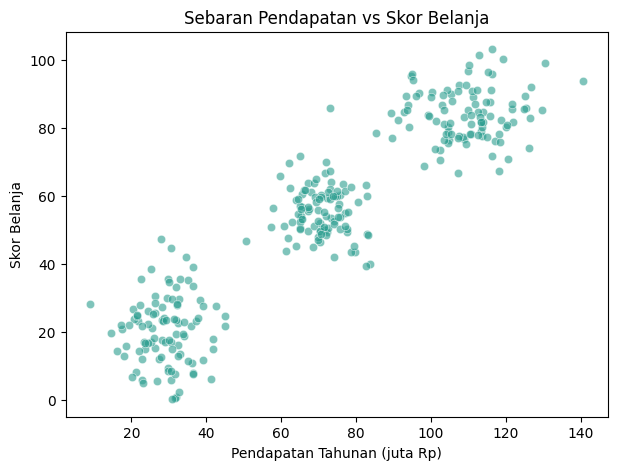

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [8, 10], (100, 2))   # hemat
grp2 = np.random.normal([70, 55], [6, 8], (100, 2))    # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))  # boros

data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print("\nStatistika Deskriptif:")
print(df.describe().round(2))

# Visualisasi awal EDA
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6, color='#2a9d8f')
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.show()

**2. Preprocessing Data**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Memilih fitur numerik utama
X = df[['pendapatan_tahunan', 'skor_belanja']].values

# Menerapkan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling:', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling: [1. 1.]


**3. Metode Elbow Untuk Menentukan K**

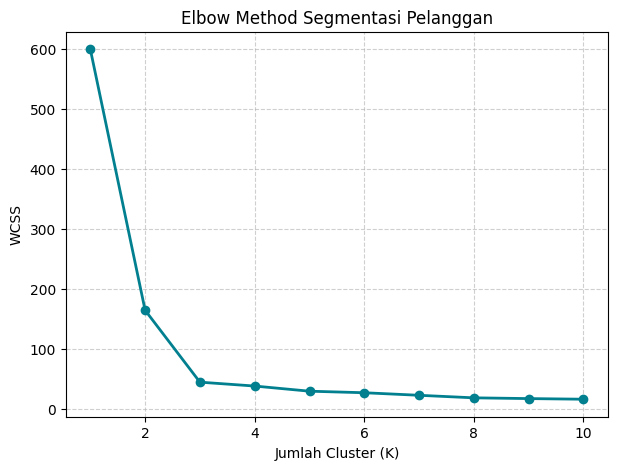

In [ ]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), wcss, marker='o', color='#028090', linewidth=2)
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method Segmentasi Pelanggan')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Analisis Grafik Elbow:**
*   **Titik Elbow:** Berdasarkan grafik di atas, penurunan nilai WCSS mulai melandai secara tajam tepat pada titik **K = 3**.
*   **Kesesuaian:** Hasil ini sangat sesuai dengan ekspektasi awal saat pembuatan dataset, di mana kita sengaja menyembunyikan 3 kelompok data (hemat, menengah, dan boros). Oleh karena itu, jumlah cluster optimal yang dipilih adalah **K = 3**.

**4. Melatih Model K-Means**

In [ ]:
from sklearn.metrics import silhouette_score

# Latih model dengan K optimal (K=3)
model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_

print(f'WCSS akhir       : {model.inertia_:.3f}')
print(f'Silhouette Score : {silhouette_score(X_scaled, model.labels_):.3f}')
print("\nNilai Rata-rata Fitur per Cluster:")
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir       : 44.919
Silhouette Score : 0.699

Nilai Rata-rata Fitur per Cluster:
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.75         55.04
1                     29.08         20.34
2                    109.19         84.01


**5. Visualisasi Hasil Clustering**

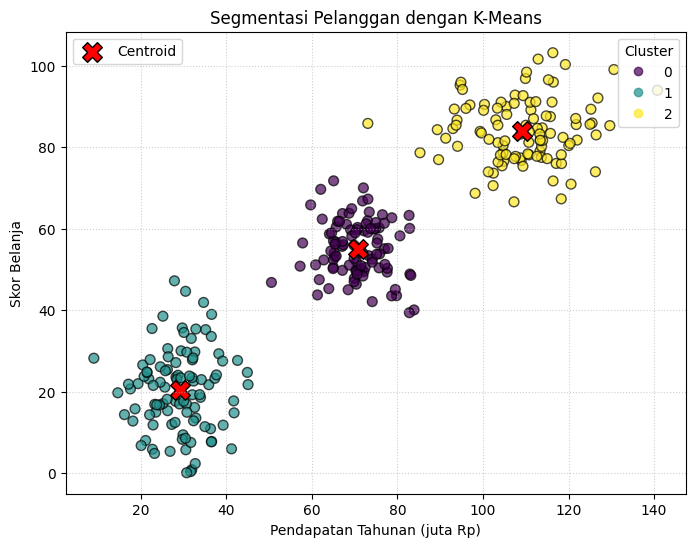

In [ ]:
# Mengembalikan posisi koordinat centroid ke skala asli
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(8, 6))

scatter_data = plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
                           c=df['cluster'], cmap='viridis', alpha=0.7, edgecolors='k', s=50)

scatter_centroid = plt.scatter(centroids[:, 0], centroids[:, 1],
                               c='red', marker='X', s=200, edgecolors='black')

plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')

legenda_cluster = plt.legend(*scatter_data.legend_elements(), title="Cluster", loc="upper right")
plt.gca().add_artist(legenda_cluster)

plt.legend([scatter_centroid], ['Centroid'], loc='upper left')

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Interpretasi Karakteristik Segmen Pelanggan:**
*   **Cluster 0 (Segmen 'Hemat'):** Pelanggan dengan pendapatan tahunan rendah dan skor pengeluaran/belanja yang juga rendah.
*   **Cluster 1 (Segmen 'Menengah'):** Pelanggan dengan tingkat pendapatan rata-rata menengah dan perilaku belanja yang stabil di tingkat menengah.
*   **Cluster 2 (Segmen 'Boros / Premium'):** Pelanggan dengan pendapatan tahunan yang tinggi disertai dengan skor perilaku belanja yang sangat tinggi.

**6. Hierachical Clustering (Perbandingan)**

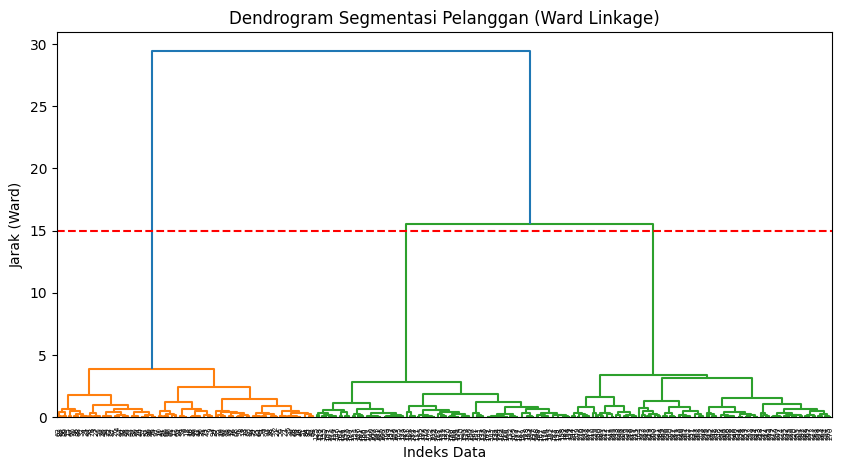

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Menggunakan metode Ward Linkage
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--') # Garis potong ambang batas
plt.show()

**Perbandingan K-Means vs Hierarchical Clustering:**
Dengan menarik garis potong horizontal pada jarak (y = 15), dendrogram terbagi menjadi **3 cluster utama**. Hasil ini **sangat konsisten** dengan jumlah K optimal yang didapatkan melalui Metode Elbow pada Langkah 3.

##  Kesimpulan

1. **Apa yang Dipelajari**:
   Penerapan algoritma *Unsupervised Learning* (K-Means & Hierarchical Clustering) untuk segmentasi data pelanggan setelah dilakukan *StandardScaler*.

2. **Temuan Utama**:
   - Jumlah kluster optimal adalah **$K = 3$** (dikonfirmasi via *Elbow Method* dan *Dendrogram*).
   - K-Means menghasilkan kelompok terpisah dengan sangat baik (*Silhouette Score* = **0.699**).
   - Terbentuk 3 profil segmen: **Hemat** (Pendapatan & Belanja Rendah), **Menengah** (Pendapatan & Belanja Sedang), dan **Boros/Premium** (Pendapatan & Belanja Tinggi).

3. **Keterbatasan & Pengembangan**:
   Pemodelan baru menggunakan 2 fitur numerik utama. Pengembangan selanjutnya dapat memasukkan variabel `usia`, `gender`, atau menggunakan algoritma berbasis kerapatan (*DBSCAN*).